In [1]:
# import dependencies
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

## Looking for mismatches:
- High Risk / Low Funding (underserved towns, case study gold)
- Low Risk / High Funding (overserved towns, allocation questions - why?)
- High Claims / Low Funding (rebuilding w/o mitigation, reactive vs proactive gap)
- Low Claims / High Funding (preventative investment? misallocation? - why?)

### Outlier Analysis: Key Findings

Outlier segmentation reveals three distinct structural patterns in flood mitigation funding across Vermont towns:

- **Underserved towns** (e.g., Winooski, Rutland, Burlington, St. Johnsbury, Johnson) tend to be more populous areas with higher socioeconomic vulnerability and moderate-to-high flood exposure, but relatively low funding per capita. This suggests a *dilution effect*, where total funding does not scale proportionally with population or need.

- **Overfunded towns** are predominantly small rural communities with very high funding per capita. In most cases, this reflects a *scale artifact*, where a single large project (e.g., buyouts or infrastructure) drives inflated per capita values in low-population areas, rather than systematic over-allocation.

- **Reactive gap towns** (e.g., Lyndon, Johnson, Barton, Cavendish) exhibit high levels of historical flood losses but comparatively low or zero mitigation funding. This represents the clearest mismatch in the dataset, suggesting that funding allocation is not consistently aligned with past damages.

- **Proactive gap towns** (e.g., Highgate) show high levels of funding despite low historical claims. These cases may reflect preventative investments, though further investigation is needed to distinguish proactive planning from potential misallocation.

Overall, the results suggest that apparent mismatches in funding are driven by a combination of **scale effects (population size), timing (reactive vs. proactive investment), and structural gaps between losses and mitigation funding**.

In [2]:
# open dfs
df = pd.read_csv("../data/cleaned/town_level_merged_for_eda.csv")
gdf = gpd.read_file("../data/cleaned/census.geojson")

# ensure types are correct for merging
df["GEOID"] = df["GEOID"].astype(str)
gdf["GEOID"] = gdf["GEOID"].astype(str)

# merge df and gdf
# df = df.merge(gdf, left_on="GEOID", right_on="GEOID")
df = gpd.GeoDataFrame(df.merge(gdf, on="GEOID", how="left"), geometry="geometry")
# df.head()

In [3]:
# add flag for small towns (distortion from small towns may be driving outliers)
df["scale_flag"] = df["total_population"] < 1000
df["scale_flag"].value_counts()

scale_flag
False    165
True      91
Name: count, dtype: int64

In [4]:
# thresholds for identifying outlier towns
high_risk = df["pct_river_corridor"] > df["pct_river_corridor"].quantile(0.75)
high_vuln = df["pct_below_poverty"] > df["pct_below_poverty"].quantile(0.75)
low_funding = (df["funding_per_capita"] == 0) | (
    df["funding_per_capita"] < df["funding_per_capita"].quantile(0.25)
)
high_funding = df["funding_per_capita"] > df["funding_per_capita"].quantile(0.75)
high_claims = df["claims_paid_per_capita"] > df["claims_paid_per_capita"].quantile(0.75)
low_claims = (df["claims_paid_per_capita"] == 0) | (
    df["claims_paid_per_capita"] < df["claims_paid_per_capita"].quantile(0.25)
)

# flag towns in each category
df["underserved"] = high_risk & high_vuln & low_funding
df["overfunded"] = (~high_risk) & (~high_vuln) & high_funding
df["reactive_gap"] = high_claims & low_funding
df["proactive_gap"] = low_claims & high_funding

In [5]:
cols = [
    "town_name",
    "total_population",
    "pct_river_corridor",
    # "pct_high_risk_NFHL",
    "pct_below_poverty",
    "percent_elderly",
    "pct_no_vehicle",
    "federalShareObligated_adj",
    "funding_per_capita",
    "funding_acquisition_buyouts",
    "funding_ecosystem_restoration",
    "funding_flood_control",
    "funding_infrastructure_stormwater",
    "total_nfip_claims_paid",
    "claims_paid_per_capita",
    "today_policies",
    "current_insurance_penetration",
    # "underserved",
    # "overfunded",
    # "reactive_gap",
    # "proactive_gap",
    "log_funding_per_capita",
    "funding_per_occupied_unit",
]

In [6]:
# display towns in each category sorted by river corridor percentage
print("Underserved towns:")
display(df[df["underserved"]][cols].sort_values("pct_river_corridor", ascending=False))
print("Overfunded towns:")
display(df[df["overfunded"]][cols].sort_values("pct_river_corridor", ascending=False))
print("Reactive gap towns:")
display(df[df["reactive_gap"]][cols].sort_values("pct_river_corridor", ascending=False))
print("Proactive gap towns:")
display(df[df["proactive_gap"]][cols].sort_values("pct_river_corridor", ascending=False))

Underserved towns:


,town_name,total_population,pct_river_corridor,pct_below_poverty,percent_elderly,pct_no_vehicle,federalShareObligated_adj,funding_per_capita,funding_acquisition_buyouts,funding_ecosystem_restoration,funding_flood_control,funding_infrastructure_stormwater,total_nfip_claims_paid,claims_paid_per_capita,today_policies,current_insurance_penetration,log_funding_per_capita,funding_per_occupied_unit
250,Winooski city,8293,20.139475,13.784705,10.900760,13.432472,49594.436068,5.980277,49594.436068,0.000000,0.0,0.0,2.276905e+04,2.745575,3.0,0.000731,1.943089,12.090306
174,Rutland city,15712,10.405589,15.317518,26.171079,12.314540,451811.488245,28.755823,451811.488245,0.000000,0.0,0.0,1.182535e+06,75.263184,76.0,0.010251,3.393025,60.940314
37,Burlington city,44675,8.667157,20.453492,12.134303,13.168419,893071.383551,19.990406,876895.106047,0.000000,0.0,0.0,8.360436e+04,1.871390,31.0,0.001771,3.044065,51.020989
194,St. Johnsbury town,7368,5.366337,16.824143,21.131922,12.767912,128086.618990,17.384177,109524.043262,0.000000,0.0,0.0,2.543808e+05,34.525083,27.0,0.008267,2.911490,39.218193
108,Johnson town,3450,4.742688,12.159054,10.753623,6.079665,40985.828386,11.879950,0.000000,40985.828386,0.0,0.0,2.859438e+06,828.822719,41.0,0.028651,2.555672,28.641390


Overfunded towns:


,town_name,total_population,pct_river_corridor,pct_below_poverty,percent_elderly,pct_no_vehicle,federalShareObligated_adj,funding_per_capita,funding_acquisition_buyouts,funding_ecosystem_restoration,funding_flood_control,funding_infrastructure_stormwater,total_nfip_claims_paid,claims_paid_per_capita,today_policies,current_insurance_penetration,log_funding_per_capita,funding_per_occupied_unit
151,Pawlet town,1480,4.304836,9.972863,27.297297,7.166667,8.529927e+05,576.346431,0.000000e+00,0.000000,0.000000,852992.718136,1.133436e+05,76.583481,7.0,0.011667,6.358442,1421.654530
154,Pittsfield town,391,4.064308,8.439898,30.434783,3.174603,1.064664e+06,2722.926337,1.064664e+06,0.000000,0.000000,0.000000,3.926194e+04,100.414164,5.0,0.026455,7.909830,5633.143904
83,Grafton town,666,3.472068,4.504505,34.234234,2.848101,9.255397e+05,1389.699229,8.303347e+05,0.000000,0.000000,65336.048131,2.640932e+05,396.536377,27.0,0.085443,7.237562,2928.923058
100,Huntington town,1853,3.369122,5.828386,18.456557,2.355713,1.022976e+06,552.064983,9.813325e+05,0.000000,0.000000,41643.887693,3.187180e+05,172.001099,23.0,0.027091,6.315476,1204.919216
22,Bolton town,1163,3.285752,2.923474,6.706793,0.729927,4.830061e+05,415.310472,2.752636e+05,0.000000,0.000000,68969.501904,6.071225e+05,522.031400,21.0,0.038321,6.031431,881.397953
127,Middlesex town,1943,3.278270,3.828246,20.638188,0.803213,3.834122e+06,1973.300035,3.819183e+06,14939.366716,0.000000,0.000000,5.654657e+05,291.027109,17.0,0.022758,7.587969,5132.693398
118,Ludlow town,1990,2.917573,5.592612,31.055276,6.852248,2.298299e+06,1154.924263,2.194612e+06,0.000000,0.000000,103686.999515,5.662924e+06,2845.690388,224.0,0.239829,7.052656,2460.705871
239,Weston town,685,2.843627,4.334828,44.233577,5.395683,4.898794e+05,715.152377,4.898794e+05,0.000000,0.000000,0.000000,1.138484e+06,1662.020006,15.0,0.053957,6.573893,1762.156038
253,Woodford town,282,2.666035,6.382979,35.106383,4.098361,5.097328e+05,1807.563203,5.097328e+05,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,7.500288,4178.137896
186,Shrewsbury town,1237,2.398637,6.952304,21.907842,0.510204,7.188644e+05,581.135288,3.594322e+05,0.000000,0.000000,0.000000,3.893775e+05,314.775682,20.0,0.051020,6.366703,1833.837630


Reactive gap towns:


,town_name,total_population,pct_river_corridor,pct_below_poverty,percent_elderly,pct_no_vehicle,federalShareObligated_adj,funding_per_capita,funding_acquisition_buyouts,funding_ecosystem_restoration,funding_flood_control,funding_infrastructure_stormwater,total_nfip_claims_paid,claims_paid_per_capita,today_policies,current_insurance_penetration,log_funding_per_capita,funding_per_occupied_unit
120,Lyndon town,5590,5.964428,11.046399,21.824687,6.279775,137227.904878,24.548820,74743.373662,62484.531216,0.0,0.00000,1.563564e+06,279.707310,36.0,0.015591,3.240591,59.431747
108,Johnson town,3450,4.742688,12.159054,10.753623,6.079665,40985.828386,11.879950,0.000000,40985.828386,0.0,0.00000,2.859438e+06,828.822719,41.0,0.028651,2.555672,28.641390
14,Barton town,2815,3.910505,10.223525,23.516874,8.588435,73970.980505,26.277435,46706.288597,20263.393039,0.0,7001.29887,1.305453e+06,463.748882,18.0,0.015306,3.306060,62.900494
43,Cavendish town,1242,3.532786,6.290850,23.590982,2.178649,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,2.128823e+06,1714.028422,40.0,0.087146,0.000000,0.000000


Proactive gap towns:


,town_name,total_population,pct_river_corridor,pct_below_poverty,percent_elderly,pct_no_vehicle,federalShareObligated_adj,funding_per_capita,funding_acquisition_buyouts,funding_ecosystem_restoration,funding_flood_control,funding_infrastructure_stormwater,total_nfip_claims_paid,claims_paid_per_capita,today_policies,current_insurance_penetration,log_funding_per_capita,funding_per_occupied_unit
96,Highgate town,3528,6.926222,8.134921,22.193878,4.557823,3.996948e+06,1132.921728,837286.618455,3.065746e+06,0.0,93915.106947,6344.641817,1.798368,7.0,0.004762,7.033437,2719.012146


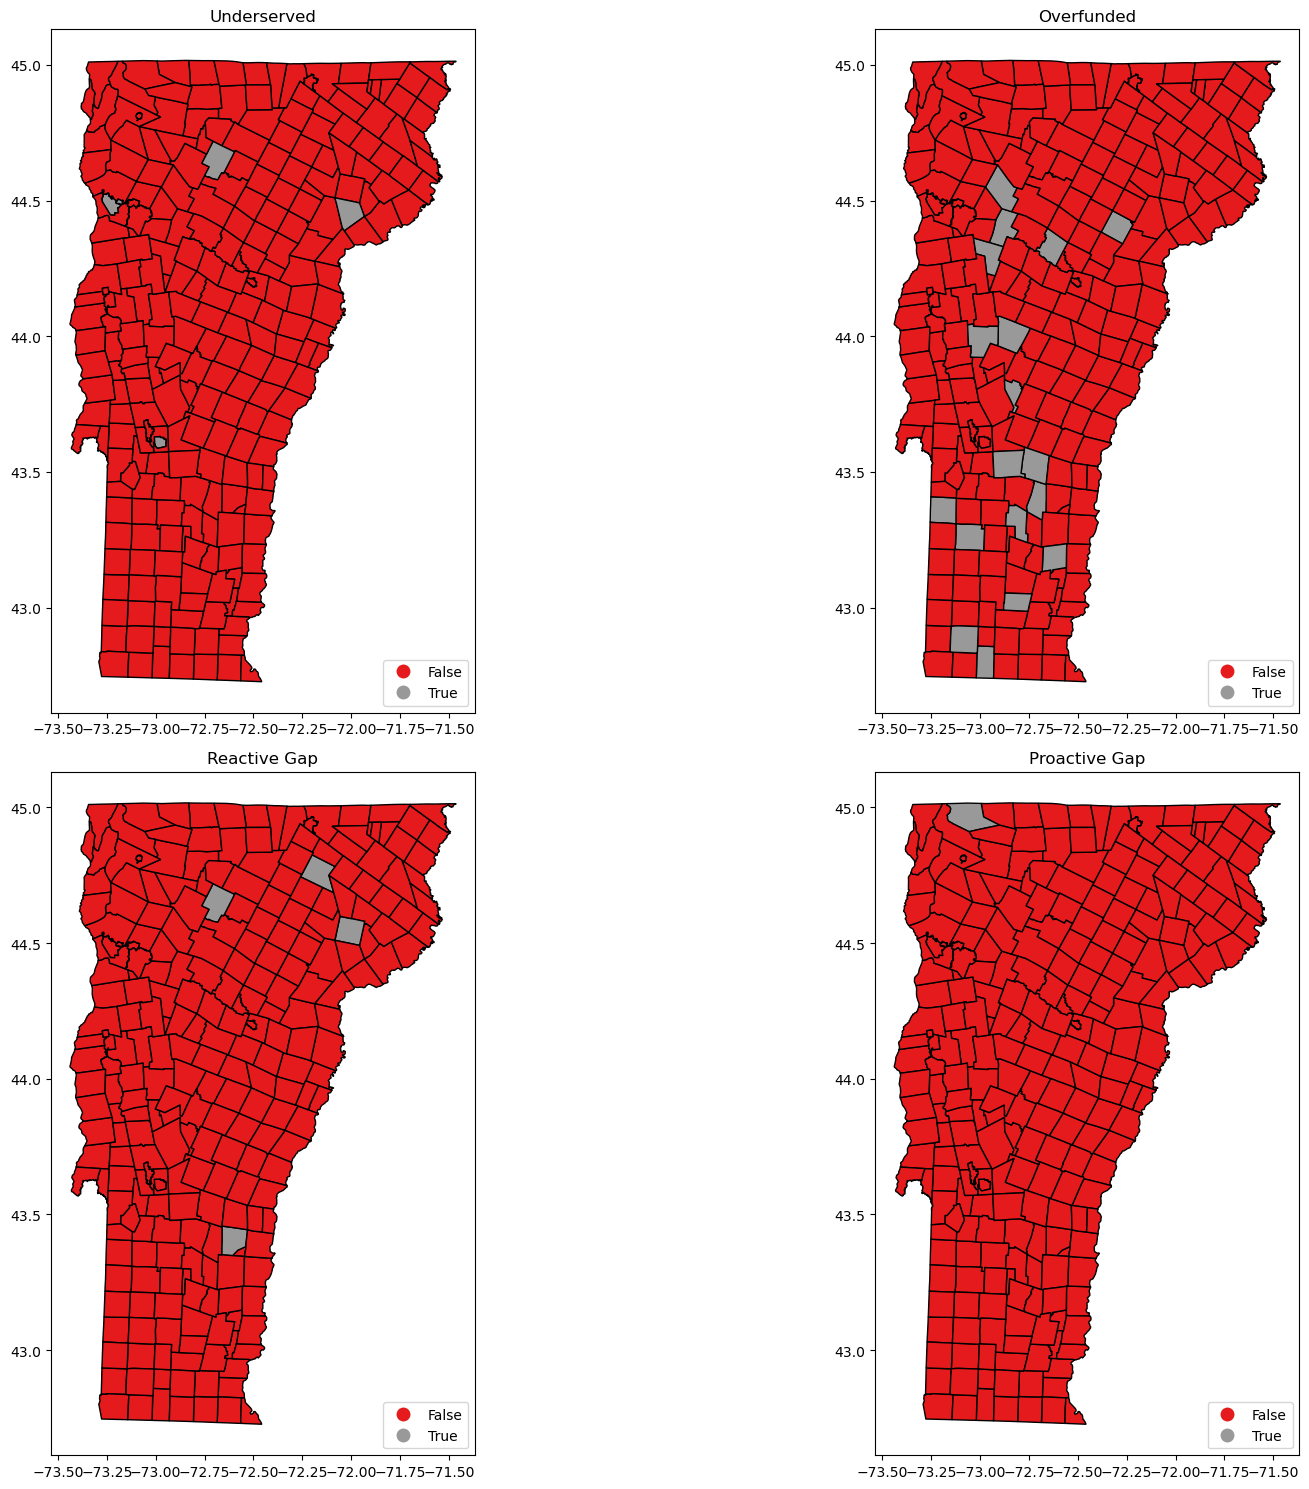

In [7]:
# choropleth maps of outlier categories
categories = ["underserved", "overfunded", "reactive_gap", "proactive_gap"]

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
for ax, category in zip(axes.flatten(), categories):
    df.plot(column=category, ax=ax, legend=True, legend_kwds={"loc": "lower right"}, cmap="Set1", edgecolor="black")
    ax.set_title(category.replace("_", " ").title())
    
plt.tight_layout()
plt.show()

In [8]:
# display value counts for small town for each category
categories = ["underserved", "overfunded", "reactive_gap", "proactive_gap"]
for category in categories:
    print(f"{category} small town value counts:")
    print(df[df[category]]["scale_flag"].value_counts())
    print()

underserved small town value counts:
scale_flag
False    5
Name: count, dtype: int64

overfunded small town value counts:
scale_flag
False    9
True     9
Name: count, dtype: int64

reactive_gap small town value counts:
scale_flag
False    4
Name: count, dtype: int64

proactive_gap small town value counts:
scale_flag
False    1
Name: count, dtype: int64



In [9]:
# display overfunded towns that are(n't) small towns
print("Overfunded towns that are small towns:")
display(df[df["overfunded"] & df["scale_flag"]][cols].sort_values("pct_river_corridor", ascending=False))
print("Overfunded towns that are not small towns:")
display(df[df["overfunded"] & ~df["scale_flag"]][cols].sort_values("pct_river_corridor", ascending=False))

Overfunded towns that are small towns:


,town_name,total_population,pct_river_corridor,pct_below_poverty,percent_elderly,pct_no_vehicle,federalShareObligated_adj,funding_per_capita,funding_acquisition_buyouts,funding_ecosystem_restoration,funding_flood_control,funding_infrastructure_stormwater,total_nfip_claims_paid,claims_paid_per_capita,today_policies,current_insurance_penetration,log_funding_per_capita,funding_per_occupied_unit
154,Pittsfield town,391,4.064308,8.439898,30.434783,3.174603,1.064664e+06,2722.926337,1.064664e+06,0.000000,0.0,0.000000,3.926194e+04,100.414164,5.0,0.026455,7.909830,5633.143904
83,Grafton town,666,3.472068,4.504505,34.234234,2.848101,9.255397e+05,1389.699229,8.303347e+05,0.000000,0.0,65336.048131,2.640932e+05,396.536377,27.0,0.085443,7.237562,2928.923058
239,Weston town,685,2.843627,4.334828,44.233577,5.395683,4.898794e+05,715.152377,4.898794e+05,0.000000,0.0,0.000000,1.138484e+06,1662.020006,15.0,0.053957,6.573893,1762.156038
253,Woodford town,282,2.666035,6.382979,35.106383,4.098361,5.097328e+05,1807.563203,5.097328e+05,0.000000,0.0,0.000000,NaN,NaN,NaN,NaN,7.500288,4178.137896
157,Plymouth town,533,2.367303,2.814259,32.645403,1.321586,7.383496e+05,1385.271371,7.383496e+05,0.000000,0.0,0.000000,6.992403e+05,1311.895421,18.0,0.079295,7.234373,3252.641589
165,Readsboro town,807,2.132440,7.347447,20.570012,7.179487,7.063342e+05,875.259281,7.063342e+05,0.000000,0.0,0.000000,NaN,NaN,1.0,0.002564,6.775662,1811.113435
86,Granville town,414,1.997686,6.038647,18.357488,1.456311,3.165701e+05,764.661990,3.165701e+05,0.000000,0.0,0.000000,2.702882e+04,65.287011,2.0,0.009709,6.640741,1536.747882
168,Ripton town,508,1.937200,8.578431,30.511811,0.000000,4.434471e+05,872.927427,2.436880e+05,165261.542448,0.0,34497.588285,1.878386e+04,36.976109,5.0,0.026738,6.772997,2371.375042
221,Wardsboro town,820,1.836929,7.682927,27.439024,0.000000,6.813189e+05,830.876745,6.813189e+05,0.000000,0.0,0.000000,3.497216e+05,426.489803,14.0,0.040698,6.723684,1980.578289


Overfunded towns that are not small towns:


,town_name,total_population,pct_river_corridor,pct_below_poverty,percent_elderly,pct_no_vehicle,federalShareObligated_adj,funding_per_capita,funding_acquisition_buyouts,funding_ecosystem_restoration,funding_flood_control,funding_infrastructure_stormwater,total_nfip_claims_paid,claims_paid_per_capita,today_policies,current_insurance_penetration,log_funding_per_capita,funding_per_occupied_unit
151,Pawlet town,1480,4.304836,9.972863,27.297297,7.166667,8.529927e+05,576.346431,0.000000e+00,0.000000,0.000000,852992.718136,1.133436e+05,76.583481,7.0,0.011667,6.358442,1421.654530
100,Huntington town,1853,3.369122,5.828386,18.456557,2.355713,1.022976e+06,552.064983,9.813325e+05,0.000000,0.000000,41643.887693,3.187180e+05,172.001099,23.0,0.027091,6.315476,1204.919216
22,Bolton town,1163,3.285752,2.923474,6.706793,0.729927,4.830061e+05,415.310472,2.752636e+05,0.000000,0.000000,68969.501904,6.071225e+05,522.031400,21.0,0.038321,6.031431,881.397953
127,Middlesex town,1943,3.278270,3.828246,20.638188,0.803213,3.834122e+06,1973.300035,3.819183e+06,14939.366716,0.000000,0.000000,5.654657e+05,291.027109,17.0,0.022758,7.587969,5132.693398
118,Ludlow town,1990,2.917573,5.592612,31.055276,6.852248,2.298299e+06,1154.924263,2.194612e+06,0.000000,0.000000,103686.999515,5.662924e+06,2845.690388,224.0,0.239829,7.052656,2460.705871
186,Shrewsbury town,1237,2.398637,6.952304,21.907842,0.510204,7.188644e+05,581.135288,3.594322e+05,0.000000,0.000000,0.000000,3.893775e+05,314.775682,20.0,0.051020,6.366703,1833.837630
59,Dorset town,2092,2.150206,11.233270,21.892925,2.505967,9.112693e+05,435.597173,9.112693e+05,0.000000,0.000000,0.000000,1.376180e+05,65.782963,10.0,0.011933,6.079011,1087.433515
38,Cabot town,1579,2.139552,9.014810,21.025966,2.101576,7.137273e+05,452.012218,0.000000e+00,9875.627292,0.000000,703851.664772,1.639723e+05,103.845640,8.0,0.014011,6.115919,1249.960231
212,Underhill town,3141,1.915762,6.367399,17.637695,0.000000,1.483331e+06,472.247910,7.450428e+05,0.000000,332622.200418,405665.666928,5.415692e+04,17.241937,13.0,0.010860,6.159619,1239.206921


In [10]:
# display funding per capita and funding per occupied unit for towns
# if both match, likely a true outlier; if they don't, likely a distortion from small town population size

# first, display quantiles for funding per capita and funding per occupied unit
print("Funding per capita and funding per occupied unit quantiles:")
print(df[["funding_per_capita", "funding_per_occupied_unit"]].describe())

# display funding per capita and funding per occupied unit for towns in each category
print("Underserved towns:")
display(df[df["underserved"]][["town_name", "funding_per_capita", "funding_per_occupied_unit"]])
print("Overfunded towns:")
display(df[df["overfunded"]][["town_name", "funding_per_capita", "funding_per_occupied_unit"]])
print("Reactive gap towns:")
display(df[df["reactive_gap"]][["town_name", "funding_per_capita", "funding_per_occupied_unit"]])
print("Proactive gap towns:")
display(df[df["proactive_gap"]][["town_name", "funding_per_capita", "funding_per_occupied_unit"]])

Funding per capita and funding per occupied unit quantiles:
       funding_per_capita  funding_per_occupied_unit
count          125.000000                 125.000000
mean           319.348988                 731.361742
std            490.864270                1081.276173
min              0.000000                   0.000000
25%             28.929119                  73.922601
50%            137.328686                 317.168058
75%            346.928271                 849.576786
max           3021.403172                5959.924960
Underserved towns:


,town_name,funding_per_capita,funding_per_occupied_unit
37,Burlington city,19.990406,51.020989
108,Johnson town,11.879950,28.641390
174,Rutland city,28.755823,60.940314
194,St. Johnsbury town,17.384177,39.218193
250,Winooski city,5.980277,12.090306


Overfunded towns:


,town_name,funding_per_capita,funding_per_occupied_unit
22,Bolton town,415.310472,881.397953
38,Cabot town,452.012218,1249.960231
59,Dorset town,435.597173,1087.433515
83,Grafton town,1389.699229,2928.923058
86,Granville town,764.661990,1536.747882
100,Huntington town,552.064983,1204.919216
118,Ludlow town,1154.924263,2460.705871
127,Middlesex town,1973.300035,5132.693398
151,Pawlet town,576.346431,1421.654530
154,Pittsfield town,2722.926337,5633.143904


Reactive gap towns:


,town_name,funding_per_capita,funding_per_occupied_unit
14,Barton town,26.277435,62.900494
43,Cavendish town,0.000000,0.000000
108,Johnson town,11.879950,28.641390
120,Lyndon town,24.548820,59.431747


Proactive gap towns:


,town_name,funding_per_capita,funding_per_occupied_unit
96,Highgate town,1132.921728,2719.012146
